# Monthly Milk Production Forecasting Using RNN, LSTM, and GRU

## Business Problem
A dairy business wants to forecast future monthly milk production to improve
supply-chain planning, inventory management, workforce allocation, and
production decisions.

## Objective
Build and compare three deep learning time-series forecasting models:
- Basic RNN
- LSTM
- GRU

The models will be evaluated using MAE, RMSE, and MAPE. Hyperparameter tuning
will also be performed using different window sizes, numbers of units, batch
sizes, and epochs. The best configuration for each model will then be used to
forecast the next 12 months.

Dataset Shape: (168, 2)


,Date,Production
0,1962-01-01,589
1,1962-02-01,561
2,1962-03-01,640
3,1962-04-01,656
4,1962-05-01,727



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168 entries, 0 to 167
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Date        168 non-null    datetime64[ns]
 1   Production  168 non-null    int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 2.8 KB

Missing Values:
Date          0
Production    0
dtype: int64

Summary Statistics:


,Date,Production
count,168,168.000000
mean,1968-12-15 16:17:08.571428572,754.708333
min,1962-01-01 00:00:00,553.000000
25%,1965-06-23 12:00:00,677.750000
50%,1968-12-16 12:00:00,761.000000
75%,1972-06-08 12:00:00,824.500000
max,1975-12-01 00:00:00,969.000000
std,NaN,102.204524


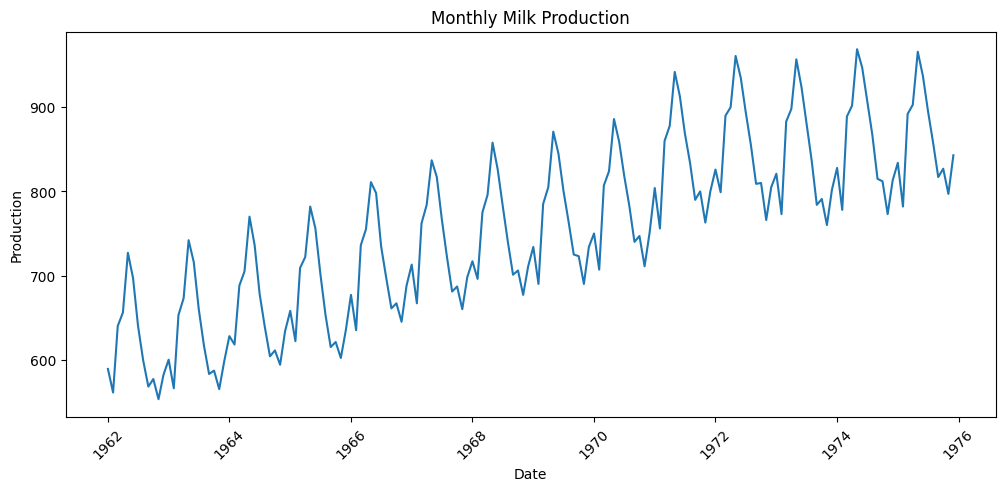

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("/content/monthly_milk_production.csv")

# Convert date and sort chronologically
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)

print("Dataset Shape:", df.shape)
display(df.head())

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nSummary Statistics:")
display(df.describe())

# Overall time-series trend
plt.figure(figsize=(12, 5))
plt.plot(df["Date"], df["Production"])
plt.title("Monthly Milk Production")
plt.xlabel("Date")
plt.ylabel("Production")
plt.xticks(rotation=45)
plt.show()

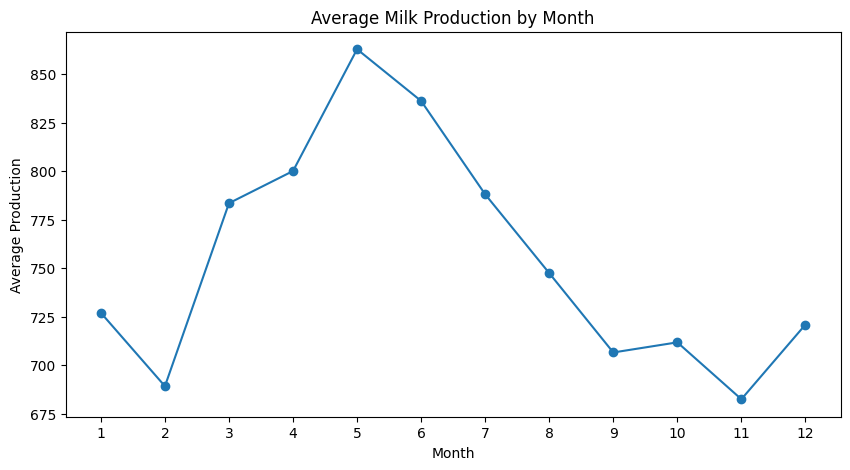

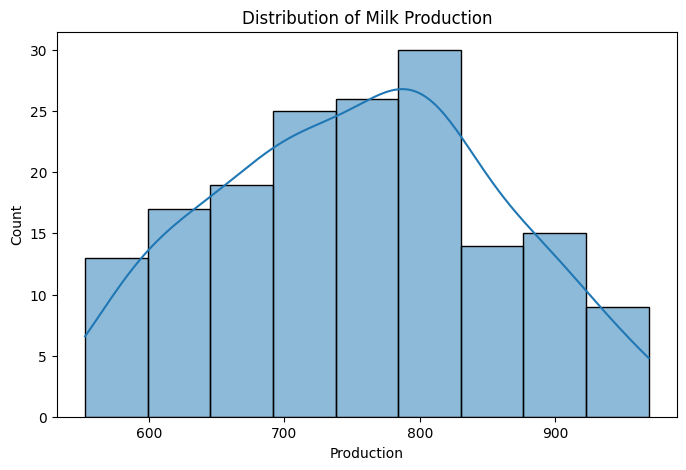

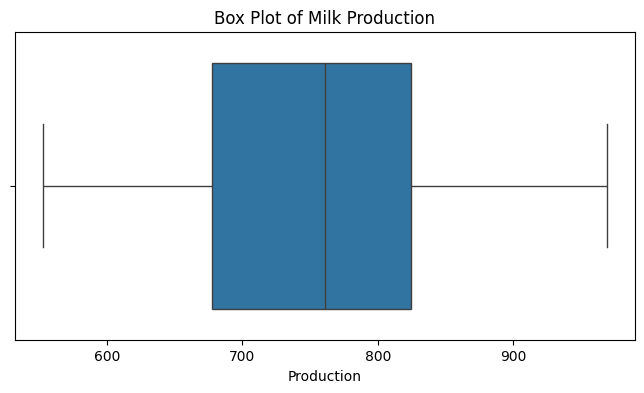

EDA Findings:
- The time-series plot shows the production trend over time.
- Monthly averages help identify recurring seasonal variation.
- The histogram shows the distribution of production values.
- The box plot helps identify possible extreme observations.
- Missing values are checked before model preparation.


In [3]:
# Exploratory Data Analysis

# Month number for seasonal analysis
df["Month"] = df["Date"].dt.month

monthly_avg = df.groupby("Month")["Production"].mean()

plt.figure(figsize=(10, 5))
plt.plot(monthly_avg.index, monthly_avg.values, marker="o")
plt.title("Average Milk Production by Month")
plt.xlabel("Month")
plt.ylabel("Average Production")
plt.xticks(range(1, 13))
plt.show()

# Distribution
plt.figure(figsize=(8, 5))
sns.histplot(df["Production"], kde=True)
plt.title("Distribution of Milk Production")
plt.xlabel("Production")
plt.show()

# Outlier check
plt.figure(figsize=(8, 4))
sns.boxplot(x=df["Production"])
plt.title("Box Plot of Milk Production")
plt.show()

print("EDA Findings:")
print("- The time-series plot shows the production trend over time.")
print("- Monthly averages help identify recurring seasonal variation.")
print("- The histogram shows the distribution of production values.")
print("- The box plot helps identify possible extreme observations.")
print("- Missing values are checked before model preparation.")

## Data Preparation

The production values are scaled using Min-Max Scaling.

For time-series forecasting, previous observations are converted into input
windows. For example, a window size of 12 means the previous 12 months are
used to predict the following month.

The data is split chronologically into training, validation, and testing sets.
The validation set is used during hyperparameter tuning.

In [4]:
from sklearn.preprocessing import MinMaxScaler

# Production values
values = df["Production"].values.reshape(-1, 1)

# Scale the complete series for sequence preparation
scaler = MinMaxScaler()
scaled_values = scaler.fit_transform(values)

def make_sequences(data, window_size):
    X, y = [], []

    for i in range(window_size, len(data)):
        X.append(data[i-window_size:i, 0])
        y.append(data[i, 0])

    X = np.array(X)
    y = np.array(y)

    X = X.reshape(X.shape[0], X.shape[1], 1)

    return X, y

def split_sequences(X, y):
    train_size = int(len(X) * 0.70)
    val_size = int(len(X) * 0.15)

    X_train = X[:train_size]
    y_train = y[:train_size]

    X_val = X[train_size:train_size + val_size]
    y_val = y[train_size:train_size + val_size]

    X_test = X[train_size + val_size:]
    y_test = y[train_size + val_size:]

    return X_train, y_train, X_val, y_val, X_test, y_test

# Initial 12-month window
X, y = make_sequences(scaled_values, 12)
X_train, y_train, X_val, y_val, X_test, y_test = split_sequences(X, y)

print("12-month window sequence shape:", X.shape)
print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))
print("Testing samples:", len(X_test))

12-month window sequence shape: (156, 12, 1)
Training samples: 109
Validation samples: 23
Testing samples: 24


## Hyperparameter Tuning

The previous submission used only one configuration, so hyperparameter tuning
is explicitly demonstrated here.

The following configurations are compared:

| Configuration | Window Size | Units | Batch Size | Epochs |
|---|---:|---:|---:|---:|
| 1 | 6 | 32 | 16 | 30 |
| 2 | 12 | 32 | 16 | 30 |
| 3 | 12 | 64 | 16 | 40 |
| 4 | 18 | 64 | 32 | 40 |

Each configuration is trained separately for RNN, LSTM, and GRU. Validation
RMSE is used to select the best configuration for each architecture.

This provides a structured comparison of window size, number of units,
batch size, and epochs.

In [5]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

configs = [
    {"name": "Config 1", "window": 6,  "units": 32, "batch": 16, "epochs": 30},
    {"name": "Config 2", "window": 12, "units": 32, "batch": 16, "epochs": 30},
    {"name": "Config 3", "window": 12, "units": 64, "batch": 16, "epochs": 40},
    {"name": "Config 4", "window": 18, "units": 64, "batch": 32, "epochs": 40}
]

def build_model(model_type, window_size, units):
    model = Sequential()

    if model_type == "RNN":
        model.add(SimpleRNN(units, input_shape=(window_size, 1)))
    elif model_type == "LSTM":
        model.add(LSTM(units, input_shape=(window_size, 1)))
    else:
        model.add(GRU(units, input_shape=(window_size, 1)))

    model.add(Dropout(0.2))
    model.add(Dense(1))

    model.compile(
        optimizer="adam",
        loss="mse"
    )

    return model

def rmse(actual, predicted):
    return np.sqrt(mean_squared_error(actual, predicted))

tuning_results = []
best_models = {}
best_configs = {}

for model_type in ["RNN", "LSTM", "GRU"]:

    best_rmse = np.inf
    best_model = None
    best_config = None

    print(f"\nTuning {model_type}...")

    for config in configs:

        X_cfg, y_cfg = make_sequences(
            scaled_values,
            config["window"]
        )

        (
            X_tr, y_tr,
            X_v, y_v,
            X_te, y_te
        ) = split_sequences(X_cfg, y_cfg)

        model = build_model(
            model_type,
            config["window"],
            config["units"]
        )

        early_stop = EarlyStopping(
            monitor="val_loss",
            patience=8,
            restore_best_weights=True
        )

        model.fit(
            X_tr,
            y_tr,
            validation_data=(X_v, y_v),
            epochs=config["epochs"],
            batch_size=config["batch"],
            callbacks=[early_stop],
            verbose=0
        )

        val_pred = model.predict(X_v, verbose=0)

        score = rmse(
            y_v,
            val_pred
        )

        tuning_results.append({
            "Model": model_type,
            "Configuration": config["name"],
            "Window Size": config["window"],
            "Units": config["units"],
            "Batch Size": config["batch"],
            "Maximum Epochs": config["epochs"],
            "Validation RMSE": score
        })

        print(
            config["name"],
            "Validation RMSE:",
            round(score, 4)
        )

        if score < best_rmse:
            best_rmse = score
            best_model = model
            best_config = config

    best_models[model_type] = best_model
    best_configs[model_type] = best_config

tuning_df = pd.DataFrame(tuning_results)

print("\nHyperparameter Tuning Results:")
display(
    tuning_df.sort_values(
        ["Model", "Validation RMSE"]
    ).round(4)
)

print("\nBest Configuration for Each Model:")

for model_type in best_configs:
    print(
        model_type,
        "->",
        best_configs[model_type],
        "| Validation RMSE:",
        round(
            tuning_df[
                (tuning_df["Model"] == model_type) &
                (tuning_df["Configuration"] == best_configs[model_type]["name"])
            ]["Validation RMSE"].iloc[0],
            4
        )
    )


Tuning RNN...


/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Config 1 Validation RMSE: 0.1167


/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Config 2 Validation RMSE: 0.0594


...

Config 3 Validation RMSE: 0.1572


/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Config 4 Validation RMSE: 0.1395

Hyperparameter Tuning Results:


,Model,Configuration,Window Size,Units,Batch Size,Maximum Epochs,Validation RMSE
11,GRU,Config 4,18,64,32,40,0.1395
10,GRU,Config 3,12,64,16,40,0.1572
9,GRU,Config 2,12,32,16,30,0.1713
8,GRU,Config 1,6,32,16,30,0.1781
6,LSTM,Config 3,12,64,16,40,0.0749
7,LSTM,Config 4,18,64,32,40,0.1416
5,LSTM,Config 2,12,32,16,30,0.1579
4,LSTM,Config 1,6,32,16,30,0.1713
3,RNN,Config 4,18,64,32,40,0.0478
2,RNN,Config 3,12,64,16,40,0.0517



Best Configuration for Each Model:
RNN -> {'name': 'Config 4', 'window': 18, 'units': 64, 'batch': 32, 'epochs': 40} | Validation RMSE: 0.0478
LSTM -> {'name': 'Config 3', 'window': 12, 'units': 64, 'batch': 16, 'epochs': 40} | Validation RMSE: 0.0749
GRU -> {'name': 'Config 4', 'window': 18, 'units': 64, 'batch': 32, 'epochs': 40} | Validation RMSE: 0.1395


## Final Model Training

The best hyperparameter configuration identified during tuning is selected
for each architecture.

The selected RNN, LSTM, and GRU models are evaluated on the unseen test data.

In [6]:
# Evaluate each best tuned model on the test set

final_results = []
test_predictions = {}

for model_type in ["RNN", "LSTM", "GRU"]:

    config = best_configs[model_type]
    model = best_models[model_type]

    X_cfg, y_cfg = make_sequences(
        scaled_values,
        config["window"]
    )

    (
        X_tr, y_tr,
        X_v, y_v,
        X_te, y_te
    ) = split_sequences(X_cfg, y_cfg)

    pred_scaled = model.predict(
        X_te,
        verbose=0
    )

    actual = scaler.inverse_transform(
        y_te.reshape(-1, 1)
    ).flatten()

    predicted = scaler.inverse_transform(
        pred_scaled
    ).flatten()

    mae = mean_absolute_error(
        actual,
        predicted
    )

    rmse_value = np.sqrt(
        mean_squared_error(
            actual,
            predicted
        )
    )

    mape = np.mean(
        np.abs((actual - predicted) / actual)
    ) * 100

    final_results.append({
        "Model": model_type,
        "Window Size": config["window"],
        "Units": config["units"],
        "Batch Size": config["batch"],
        "Epochs": config["epochs"],
        "MAE": mae,
        "RMSE": rmse_value,
        "MAPE (%)": mape
    })

    test_predictions[model_type] = {
        "actual": actual,
        "predicted": predicted
    }

results_df = pd.DataFrame(final_results)

print("Final Test Performance:")
display(results_df.round(2))

best_model_name = results_df.loc[
    results_df["RMSE"].idxmin(),
    "Model"
]

print(
    "Best final model based on lowest test RMSE:",
    best_model_name
)

Final Test Performance:


,Model,Window Size,Units,Batch Size,Epochs,MAE,RMSE,MAPE (%)
0,RNN,18,64,32,40,17.87,20.02,2.07
1,LSTM,12,64,16,40,20.61,28.55,2.42
2,GRU,18,64,32,40,50.44,59.04,5.78


Best final model based on lowest test RMSE: RNN


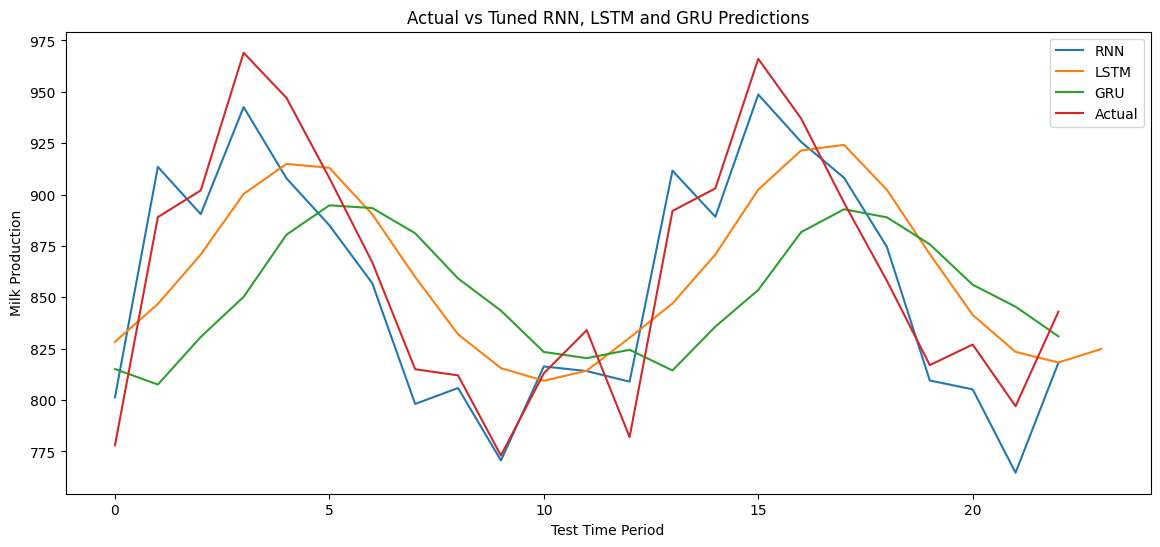

In [7]:
# Actual vs predicted values

plt.figure(figsize=(14, 6))

for model_type in ["RNN", "LSTM", "GRU"]:
    plt.plot(
        test_predictions[model_type]["predicted"],
        label=model_type
    )

plt.plot(
    test_predictions["RNN"]["actual"],
    label="Actual"
)

plt.title(
    "Actual vs Tuned RNN, LSTM and GRU Predictions"
)

plt.xlabel("Test Time Period")
plt.ylabel("Milk Production")
plt.legend()
plt.show()

## Forecasting the Next 12 Months and Business Insights

The best-performing tuned model based on test RMSE is used to forecast the
next 12 months.

### Business Insights

The forecasts can help the dairy business:
- Plan milk collection and storage capacity.
- Manage workforce requirements.
- Prepare transportation and distribution.
- Plan inventory and supply-chain activities.
- Anticipate seasonal changes in production.
- Make better production and resource allocation decisions.

### Conclusion

RNN, LSTM, and GRU models were developed and compared. Unlike the original
submission, multiple hyperparameter configurations were systematically tested
using validation RMSE.

Window size, number of units, batch size, and maximum epochs were varied.
The best configuration for each architecture was then evaluated on unseen
test data.

The model with the lowest test RMSE is selected for the final 12-month
forecast.

Best tuned model used for forecasting: RNN
Best configuration:
{'name': 'Config 4', 'window': 18, 'units': 64, 'batch': 32, 'epochs': 40}

Next 12 Months Forecast:


,Date,Forecasted Production
0,1976-01-01,820.299988
1,1976-02-01,838.869995
2,1976-03-01,879.549988
3,1976-04-01,926.200012
4,1976-05-01,928.989990
5,1976-06-01,941.080017
6,1976-07-01,878.049988
7,1976-08-01,868.299988
8,1976-09-01,808.469971
9,1976-10-01,827.130005


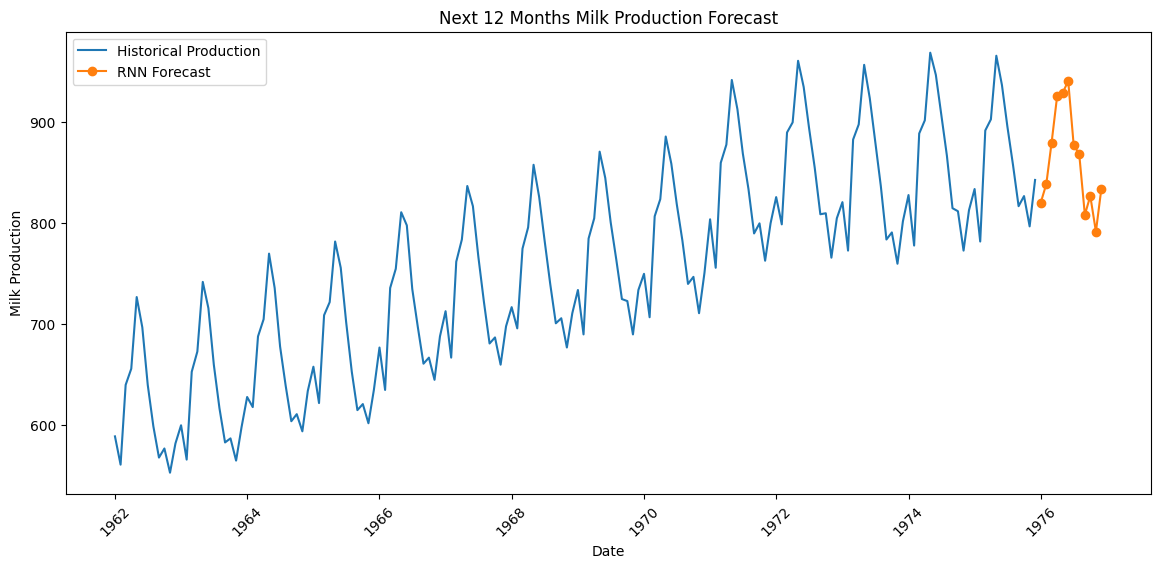

In [8]:
# Select the best tuned architecture
best_model = best_models[best_model_name]
best_config = best_configs[best_model_name]

# Start with the latest window from the full historical dataset
last_sequence = scaled_values[-best_config["window"]:].copy()

future_predictions = []

for _ in range(12):

    current_input = last_sequence.reshape(
        1,
        best_config["window"],
        1
    )

    next_scaled = best_model.predict(
        current_input,
        verbose=0
    )[0, 0]

    future_predictions.append(next_scaled)

    last_sequence = np.append(
        last_sequence[1:],
        next_scaled
    )

# Convert predictions to original scale
future_predictions = scaler.inverse_transform(
    np.array(future_predictions).reshape(-1, 1)
).flatten()

# Future dates
last_date = df["Date"].max()

future_dates = pd.date_range(
    start=last_date + pd.DateOffset(months=1),
    periods=12,
    freq="MS"
)

forecast_df = pd.DataFrame({
    "Date": future_dates,
    "Forecasted Production": future_predictions
})

print(
    f"Best tuned model used for forecasting: {best_model_name}"
)

print("Best configuration:")
print(best_config)

print("\nNext 12 Months Forecast:")
display(forecast_df.round(2))

# Historical + future forecast plot
plt.figure(figsize=(14, 6))

plt.plot(
    df["Date"],
    df["Production"],
    label="Historical Production"
)

plt.plot(
    future_dates,
    future_predictions,
    marker="o",
    label=f"{best_model_name} Forecast"
)

plt.title(
    "Next 12 Months Milk Production Forecast"
)

plt.xlabel("Date")
plt.ylabel("Milk Production")
plt.legend()
plt.xticks(rotation=45)

plt.show()